In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('./dataset_7_18.csv')

# 分离特征和标签
X = df.iloc[:, :-1]  # 除最后一列外的所有列作为特征
y = df.iloc[:, -1]   # 最后一列作为标签

# 标准化数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 执行PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 计算累积解释方差比
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# 绘制碎石图
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         cumulative_variance_ratio, 'bo-')
plt.xlabel('主成分数量')
plt.ylabel('累积解释方差比')
plt.title('PCA累积解释方差比')
plt.grid(True)
plt.savefig('pca_variance_ratio.png')
plt.close()

n_features = X.shape[1]
n_components = n_features // 2
# 选择前两个主成分进行可视化
pca_2d = PCA(n_components=n_components)
X_pca_2d = pca_2d.fit_transform(X_scaled)
# 创建多列名称
column_names = [f'PC{i+1}' for i in range(n_components)]

# ... existing code ...


# 创建散点图
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis')
plt.colorbar(scatter)
plt.xlabel('第一主成分')
plt.ylabel('第二主成分')
plt.title('PCA降维后的数据分布')
plt.savefig('pca_scatter.png')
plt.close()

# 输出主成分的解释方差比
print("\n前10个主成分的解释方差比:")
for i, ratio in enumerate(pca.explained_variance_ratio_[:10], 1):
    print(f"PC{i}: {ratio:.4f}")

# 输出累积解释方差比
print("\n前10个主成分的累积解释方差比:")
for i, ratio in enumerate(cumulative_variance_ratio[:10], 1):
    print(f"PC1-PC{i}: {ratio:.4f}")

# 保存降维后的数据
pca_df = pd.DataFrame(X_pca_2d, columns=column_names)
pca_df['emi_cat'] = y
pca_df.to_csv('pca_results.csv', index=False)

C:\Users\IMP\AppData\Local\Temp\ipykernel_33112\3189268362.py:33: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_variance_ratio.png')
C:\Users\IMP\AppData\Local\Temp\ipykernel_33112\3189268362.py:33: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_variance_ratio.png')
C:\Users\IMP\AppData\Local\Temp\ipykernel_33112\3189268362.py:33: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_variance_ratio.png')
C:\Users\IMP\AppData\Local\Temp\ipykernel_33112\3189268362.py:33: UserWarning: Glyph 37322 (\N{CJK UNIFIED IDEOGRAPH-91CA}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_variance_ratio.png')
C:\Users\IMP\AppData\Local\Temp\ipykernel_33112\3189268362.py:33: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_variance_ratio.png')
C:\Users\I


前10个主成分的解释方差比:
PC1: 0.0578
PC2: 0.0372
PC3: 0.0334
PC4: 0.0328
PC5: 0.0314
PC6: 0.0298
PC7: 0.0284
PC8: 0.0282
PC9: 0.0258
PC10: 0.0256

前10个主成分的累积解释方差比:
PC1-PC1: 0.0578
PC1-PC2: 0.0951
PC1-PC3: 0.1285
PC1-PC4: 0.1613
PC1-PC5: 0.1926
PC1-PC6: 0.2224
PC1-PC7: 0.2509
PC1-PC8: 0.2791
PC1-PC9: 0.3049
PC1-PC10: 0.3305


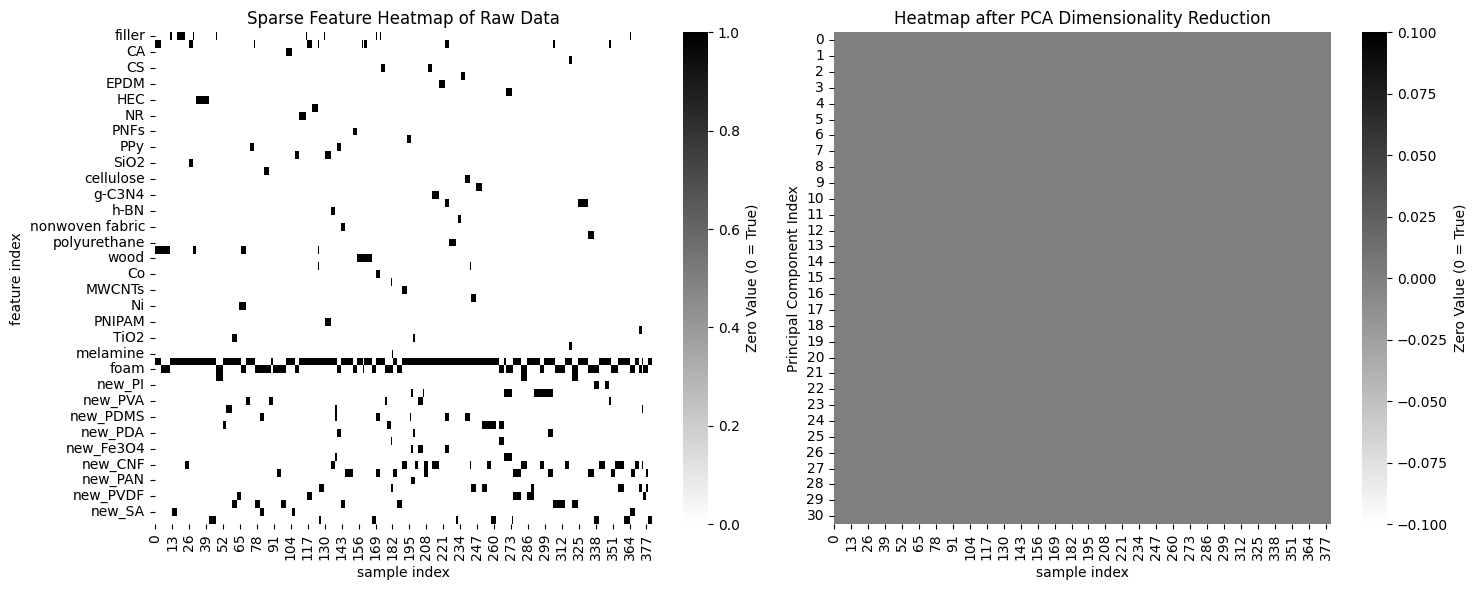

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from matplotlib.colors import ListedColormap
import seaborn as sns

# 假设X是原始数据矩阵
# X = ... (你的原始数据)
# 


df = pd.read_csv('./dataset_7_18.csv')

# 分离特征和标签
X = df.iloc[:, :-1]

plt.figure(figsize=(15, 6))

# custom_cmap = ListedColormap(['#DDE4EC', '#FBE5D6'])
# 原始数据热力图
plt.subplot(1, 2, 1)
sns.heatmap(X.T == 1, cmap="binary", cbar_kws={'label': 'Zero Value (0 = True)'})
plt.title('Sparse Feature Heatmap of Raw Data')
plt.xlabel('sample index')
plt.ylabel('feature index')


# plt.imshow(X.T == 1, aspect='auto', cmap='binary', interpolation='nearest')
# plt.colorbar(label='Zero Value (0 = True)')
# plt.title('Sparse Feature Heatmap of Raw Data')
# plt.xlabel('sample index')
# plt.ylabel('feature index')

# 降维后数据热力图
plt.subplot(1, 2, 2)
sns.heatmap(X_pca.T == 1, cmap="binary", cbar_kws={'label': 'Zero Value (0 = True)'})
plt.title('Heatmap after PCA Dimensionality Reduction')
plt.xlabel('sample index')
plt.ylabel('Principal Component Index')



# plt.imshow(X_pca.T == 1, aspect='auto', cmap='binary', interpolation='nearest')
# plt.colorbar(label='Zero Value (0 = True)') 
# plt.title('Heatmap of Feature Sparsity after PCA Dimensionality Reduction')
# plt.xlabel('sample index')
# plt.ylabel('Principal Component Index')

plt.tight_layout()
plt.savefig('g:\\VScode\\Mxene-7-12\\sparsity_heatmap_comparison.svg')
plt.show()

In [ ]:
#特征重要性可视化



,filler,thickness（mm）,CA,CNC,CS,Cellulose microspheres,EPDM,GO,HEC,MMT,...,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF,emi_cat
0,0.900000,1.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.0
1,0.800000,1.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.0
2,0.700000,1.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
3,0.600000,1.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
4,0.600000,1.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,0.600098,3.000,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,2.0
378,0.799805,3.100,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,2.0
379,0.500000,0.031,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1.0
380,0.600098,0.040,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1.0
